In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.analysis import plot_summary

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
x_o = np.loadtxt('../data/x_o.csv', delimiter=",")
x_o

array([0.20859493, 0.12730937, 0.09281016, 0.0675    , 0.1225    ,
       0.1625    , 0.03138889, 0.31841391])

In [3]:
x_o_2000 = np.append(x_o, 2000.0)
x_o_2000 = torch.tensor(x_o_2000, device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)
x_o_2000 = x_o_2000.flatten()
x_o_2000_numpy = x_o_2000.cpu().numpy()
x_o_2000

tensor([2.0859e-01, 1.2731e-01, 9.2810e-02, 6.7500e-02, 1.2250e-01, 1.6250e-01,
        3.1389e-02, 3.1841e-01, 2.0000e+03])

In [4]:
x_o_500 = np.append(x_o, 500.0)
x_o_500 = torch.tensor(x_o_500, device=torch_device)
x_o_500 = x_o_500.to(torch.float32)
x_o_500 = x_o_500.flatten()
x_o_500_numpy = x_o_500.cpu().numpy()
x_o_500

tensor([2.0859e-01, 1.2731e-01, 9.2810e-02, 6.7500e-02, 1.2250e-01, 1.6250e-01,
        3.1389e-02, 3.1841e-01, 5.0000e+02])

In [5]:
x_o_4000 = np.append(x_o, 4000.0)
x_o_4000 = torch.tensor(x_o_4000, device=torch_device)
x_o_4000 = x_o_4000.to(torch.float32)
x_o_4000 = x_o_4000.flatten()
x_o_4000_numpy = x_o_4000.cpu().numpy()
x_o_4000

tensor([2.0859e-01, 1.2731e-01, 9.2810e-02, 6.7500e-02, 1.2250e-01, 1.6250e-01,
        3.1389e-02, 3.1841e-01, 4.0000e+03])

In [6]:
checkpoint = np.load('../data/simulation_checkpoint_latest.npz')

theta = checkpoint['theta']
x = checkpoint['x']
simulations_finished = checkpoint['completed']

In [7]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()
theta

tensor([[1.0976e-01, 1.4304e-01, 4.9590e+03],
        [1.0976e-01, 1.4304e-01, 1.1330e+03],
        [1.0976e-01, 1.4304e-01, 4.4730e+03],
        ...,
        [1.7202e-01, 6.2670e-02, 4.8140e+03],
        [1.7202e-01, 6.2670e-02, 4.6930e+03],
        [1.7202e-01, 6.2670e-02, 2.2500e+02]])

In [8]:
x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()
x

tensor([[1.1321e-01, 7.5035e-02, 5.9873e-02,  ..., 1.6918e-01, 5.6627e-01,
         4.9590e+03],
        [1.1566e-01, 6.5609e-02, 5.8818e-02,  ..., 1.6531e-01, 5.6388e-01,
         1.1330e+03],
        [1.1149e-01, 7.2697e-02, 5.8645e-02,  ..., 1.6975e-01, 5.6529e-01,
         4.4730e+03],
        ...,
        [9.8416e-02, 6.9605e-02, 5.5942e-02,  ..., 1.0236e-01, 4.5454e-01,
         4.8140e+03],
        [1.0317e-01, 7.4163e-02, 5.8042e-02,  ..., 1.0208e-01, 4.5372e-01,
         4.6930e+03],
        [8.5503e-02, 6.1937e-02, 6.6334e-02,  ..., 1.0321e-01, 4.6235e-01,
         2.2500e+02]])

In [9]:
theta.shape, x.shape

(torch.Size([50000, 3]), torch.Size([50000, 9]))

In [10]:
x_o_2000.dtype, x_o_500.dtype, x_o_4000.dtype, theta.dtype, x.dtype

(torch.float32, torch.float32, torch.float32, torch.float32, torch.float32)

In [11]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [12]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 164 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-04-13T13_12_24.260169' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


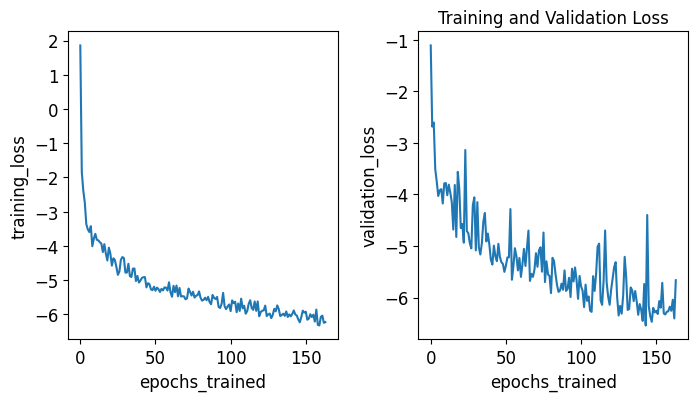

In [13]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

In [15]:
theta_trained_2000 = posterior.set_default_x(x_o_2000).sample((num_posterior_samples,), x=x_o_2000)
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 43020.27it/s]


In [16]:
theta_trained_500 = posterior.set_default_x(x_o_500).sample((num_posterior_samples,), x=x_o_500)
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 39537.57it/s]


In [17]:
theta_trained_4000 = posterior.set_default_x(x_o_4000).sample((num_posterior_samples,), x=x_o_4000)
theta_trained_4000_numpy = theta_trained_4000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 43212.18it/s]


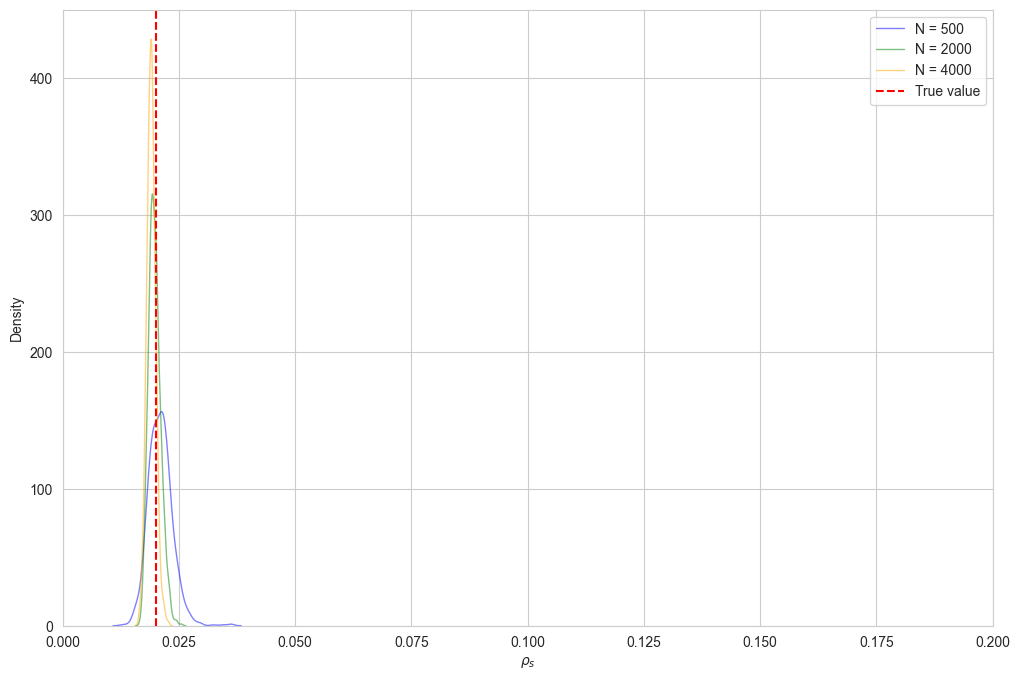

In [18]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_4000_numpy[:, 0], label='N = 4000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

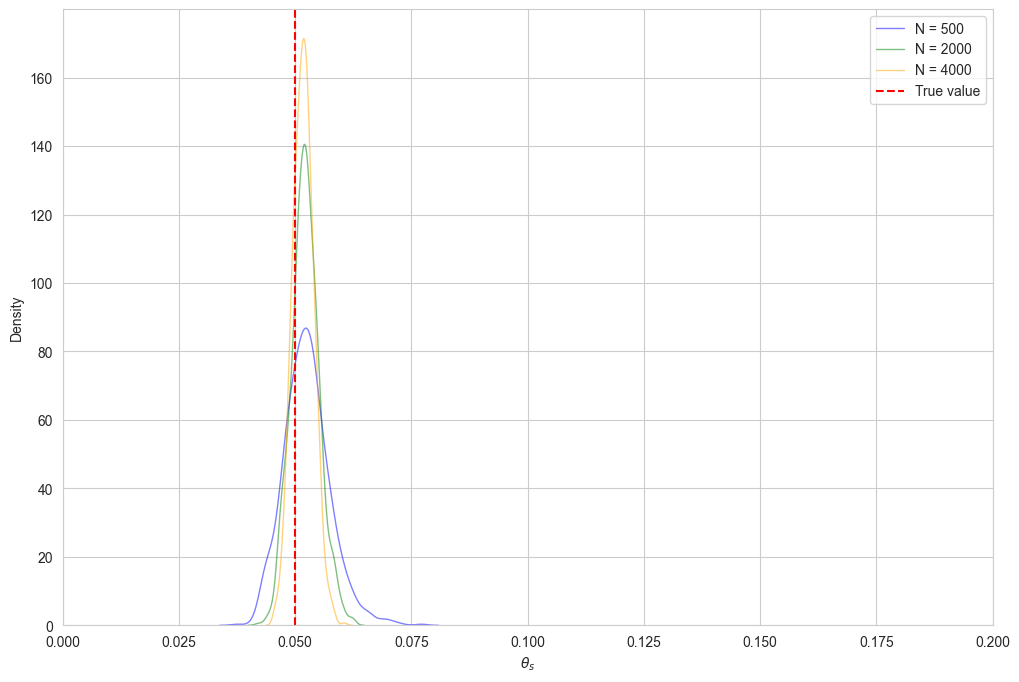

In [19]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_4000_numpy[:, 1], label='N = 4000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

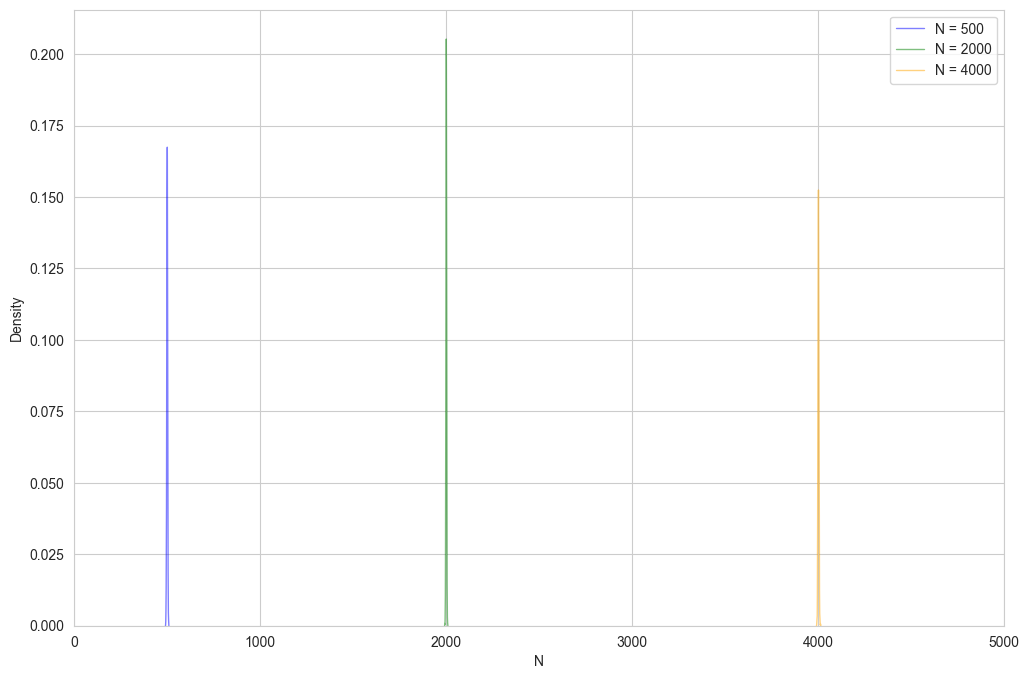

In [20]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 2], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 2], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_4000_numpy[:, 2], label='N = 4000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(0.0, 5000.0)
plt.legend()
plt.show()

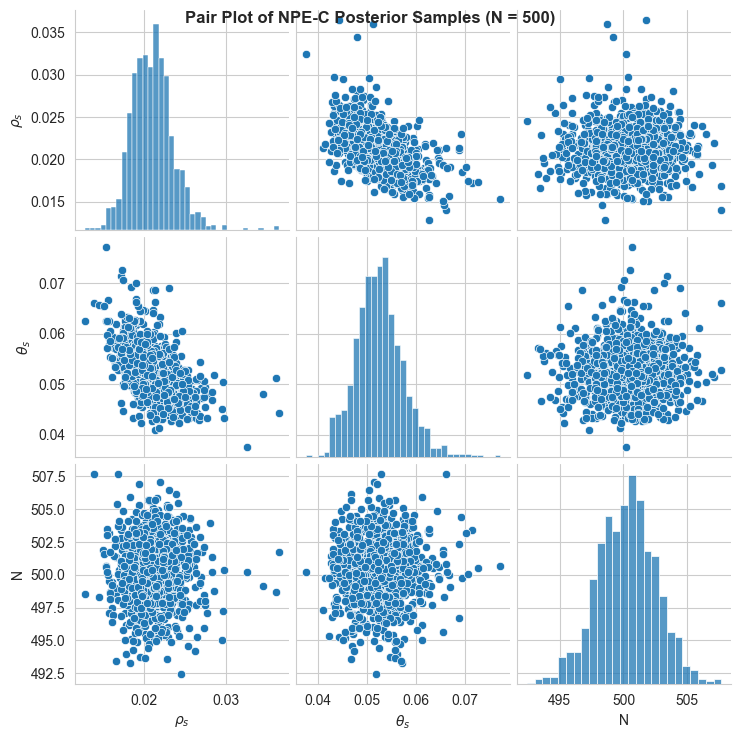

In [21]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

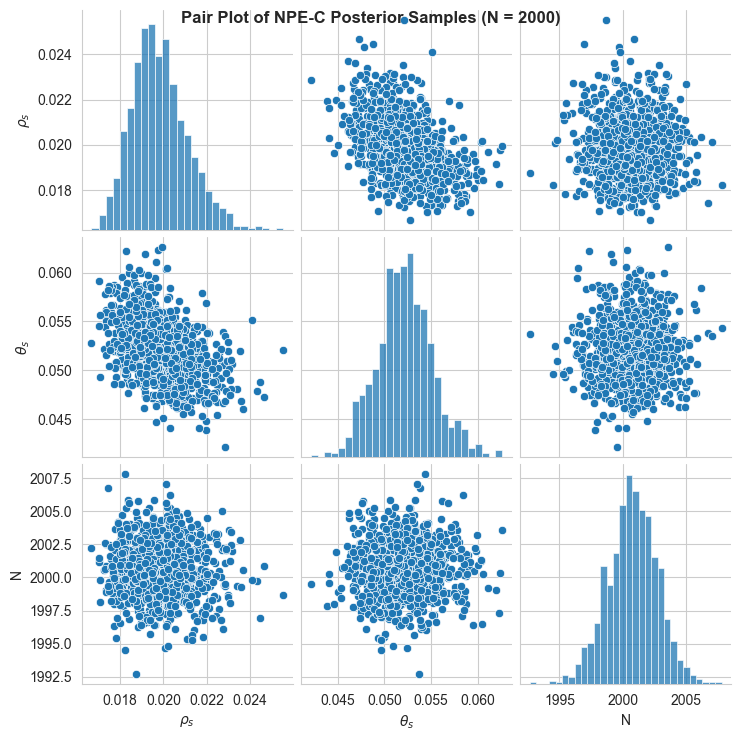

In [22]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

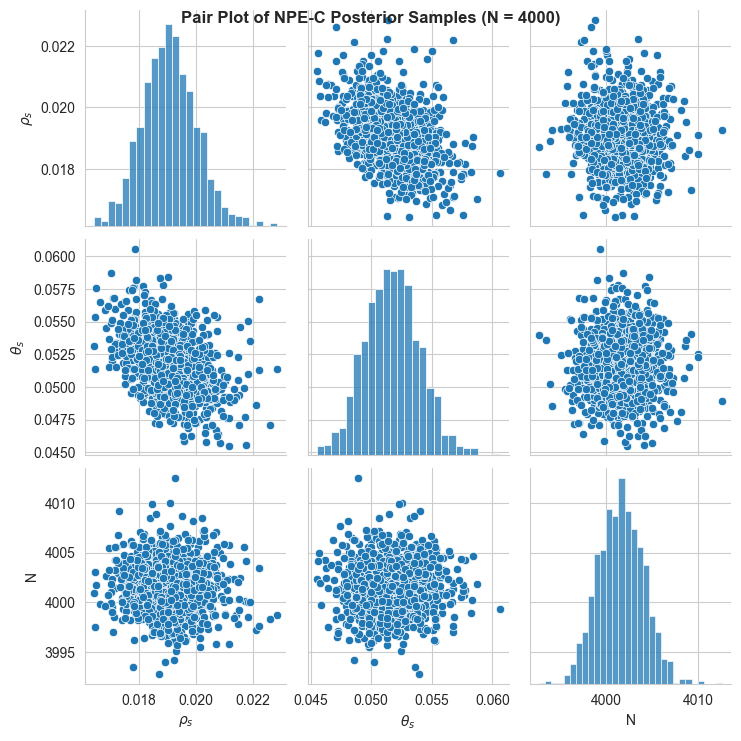

In [23]:
df_4000 = pd.DataFrame(theta_trained_4000_numpy, columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_4000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 4000)', fontsize=12, fontweight='bold')
plt.show()